### Problem Statement

Telecommunication companies lose revenue when customers cancel their services. Customer churn is costly because acquiring new customers is usually more expensive than retaining existing ones. The objective of this analysis is to identify patterns and factors associated with customer churn, helping the company understand which customers are most likely to leave.

In [1]:
#import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the dataset
data=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

#Lets get an overview of the dataset
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
#lets see the dataset shape
data.shape

(7043, 21)

In [4]:
sns.set_style("whitegrid")
#for better visuals

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
#Problem
#Totalcharges should be numeric, but it is stored as an object(text)
#If left like this we can't calculate statistics or correlations with this column

data["TotalCharges"]=pd.to_numeric(data["TotalCharges"],errors="coerce")

#erros="coerce" converts any non-numeric values into NAN(missing values)


#### CHECK MISSING VALUES

In [7]:
data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

#### REMOVE THE MISSING VALUES

In [8]:
data.dropna(inplace=True)

In [9]:
#Lets check for missing values
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

### CHURN ANALYSIS

In [11]:
#What is the churn rate?
data["Churn"].value_counts()


Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [12]:
#In percentage
data["Churn"].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

Approximately 27% of customers have churned, while the majority remain with the company.

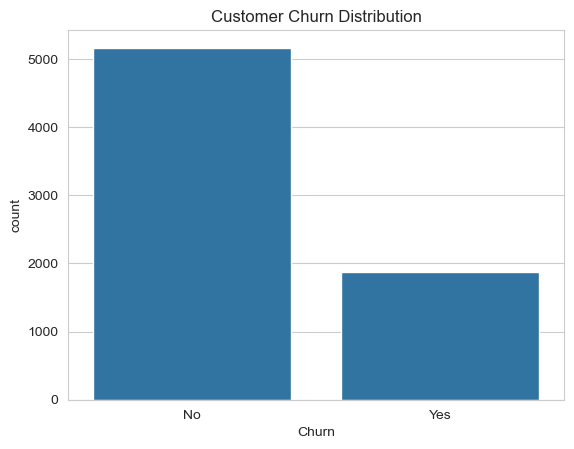

In [14]:
plt.Figure(figsize=(6,4))
sns.countplot(x="Churn",data=data)
plt.title("Customer Churn Distribution")
plt.show()

##### 1. Does Contract type influence customer churn?

In [15]:
data["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [16]:
pd.crosstab(data["Contract"],data["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [17]:
pd.crosstab(data["Contract"],data["Churn"],normalize="index")*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


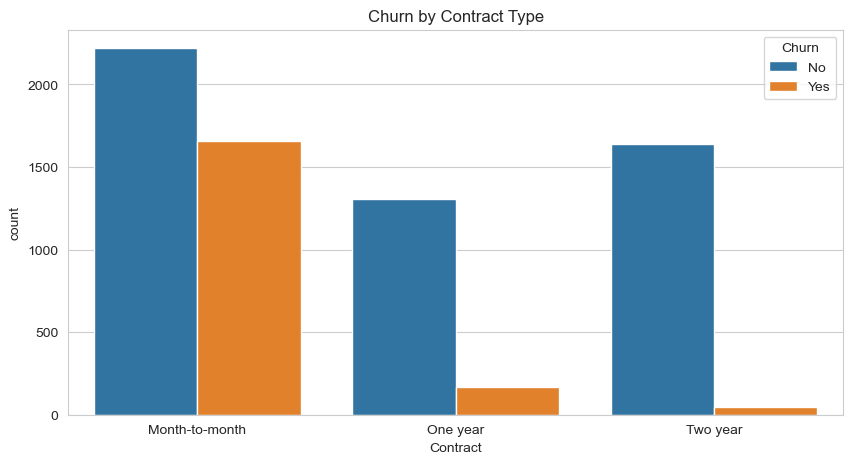

In [19]:
#lets visualize the contract relatioship with churn
plt.figure(figsize=(10,5))
sns.countplot(x="Contract",hue="Churn",data=data)
plt.title("Churn by Contract Type")
plt.show()

Customers with Month-to-Month contracts have the highest rate, while customers with one-year and two-year contracts are most likely to stay withe the company. This suggests that longer contract commitments help reduce customer churn.

#### 2. Do customers who stay longer churn less?

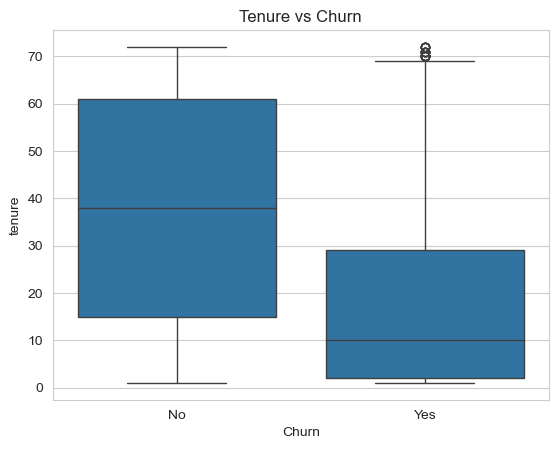

In [26]:
plt.Figure(figsize=(8,5))
sns.boxplot(x="Churn",y="tenure",data=data)
plt.title("Tenure vs Churn")
plt.show()

Customers wth shorter tenure are significantly more likely to churn. This suggests that the first few months of a customer's subscription are the most critical for retention. Customers who remain with the company for longer periods tend to stay loyal.

1. Company should include discounts for new customers.

2. Loyalty incentives should also be included to make the customers stay loyal.

3. Onboarding programs.

##### 3. Do customers paying high monthly fees churn more?

In [28]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [30]:
data.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


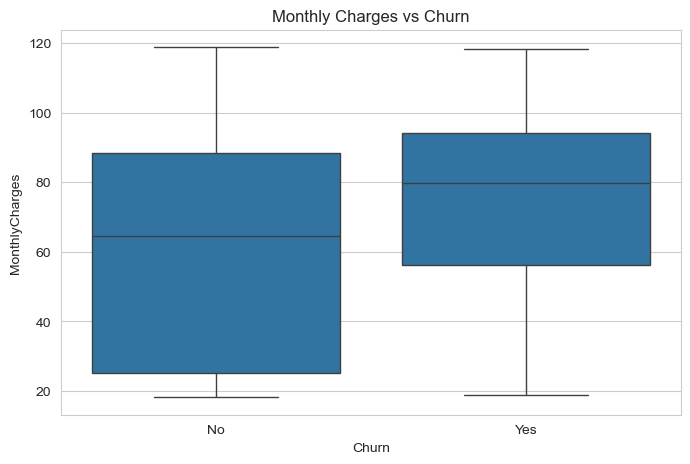

In [31]:
#visual
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=data)
plt.title("Monthly Charges vs Churn")
plt.show()

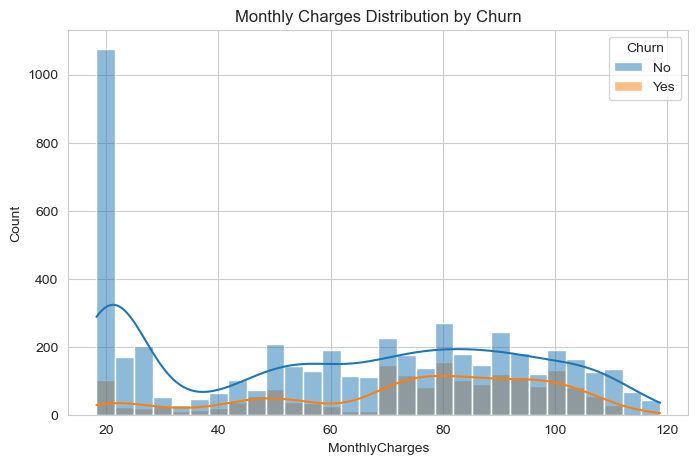

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(data=data, x="MonthlyCharges", hue="Churn", bins=30, kde=True)
plt.title("Monthly Charges Distribution by Churn")
plt.show()

Customers who churn tend to have higher monthly charges compared to those who remain with the company. This suggests that pricing or perceived value of services may influence customer retention.